In [ ]:
# Cell 0: Setup ProteinMPNN
import torch, os

print("GPU available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

!git clone https://github.com/dauparas/ProteinMPNN.git
%cd /content/ProteinMPNN

!ls protein_mpnn_run.py
print("✓ ProteinMPNN ready")

GPU available: False
Cloning into 'ProteinMPNN'...
remote: Enumerating objects: 634, done.
remote: Counting objects: 100% (271/271), done.
remote: Compressing objects: 100% (125/125), done.
remote: Total 634 (delta 151), reused 146 (delta 146), pack-reused 363 (from 1)
Receiving objects: 100% (634/634), 119.90 MiB | 30.87 MiB/s, done.
Resolving deltas: 100% (290/290), done.
/content/ProteinMPNN
protein_mpnn_run.py
✓ ProteinMPNN ready


In [ ]:
# ============================================================
# Cell 1: Setup (see Stage 0 Colab header for ProteinMPNN install)
# ============================================================
# Run ProteinMPNN setup cell from Section 2.4

# Upload your filtered backbone designs
from google.colab import drive
drive.mount('/content/drive')

PROJECT_DIR = "/content/drive/Othercomputers/My Mac/pdl1-mini-binder-design"

INPUT_DIR = "/content/drive/MyDrive/Colab Notebooks/rfdiffusion_outputs"
OUTPUT_DIR = f"{PROJECT_DIR}/data/results/proteinmpnn"

!ls "$INPUT_DIR" | head
!mkdir -p "$OUTPUT_DIR"

print("✓ Project connected")
print("✓ RFdiffusion outputs found")

Mounted at /content/drive
all_design_geometry_metrics.csv
design_0_0.pdb
design_0_0.trb
design_10_0.pdb
design_10_0.trb
design_1_0.pdb
design_1_0.trb
design_11_0.pdb
design_11_0.trb
design_12_0.pdb
✓ Project connected
✓ RFdiffusion outputs found


In [ ]:
# Cell 2: Prepare ProteinMPNN chain assignment

%cd /content/ProteinMPNN

PARSED_JSONL = f"{OUTPUT_DIR}/parsed_pdbs.jsonl"
ASSIGNED_JSONL = f"{OUTPUT_DIR}/assigned_pdbs.jsonl"

# Parse all chains from RFdiffusion PDBs
!python helper_scripts/parse_multiple_chains.py \
    --input_path "$INPUT_DIR" \
    --output_path "$PARSED_JSONL"

# Design only binder chain B; keep target chain A fixed
!python helper_scripts/assign_fixed_chains.py \
    --input_path "$PARSED_JSONL" \
    --output_path "$ASSIGNED_JSONL" \
    --chain_list "B"

print("✓ Parsed PDBs and assigned design chain B")

/content/ProteinMPNN
✓ Parsed PDBs and assigned design chain B


In [ ]:
# Cell 3: Run ProteinMPNN

%cd /content/ProteinMPNN

SEQS_PER_DESIGN = 8
TEMPERATURE = 0.1

import subprocess, os

cmd = [
    "python",
    "protein_mpnn_run.py",
    "--jsonl_path", PARSED_JSONL,
    "--chain_id_jsonl", ASSIGNED_JSONL,
    "--out_folder", OUTPUT_DIR,
    "--num_seq_per_target", str(SEQS_PER_DESIGN),
    "--sampling_temp", str(TEMPERATURE),
    "--batch_size", "1",
]

result = subprocess.run(
    cmd,
    capture_output=True,
    text=True,
    env=os.environ.copy()
)

print(result.stdout)
print(result.stderr)

if result.returncode != 0:
    raise RuntimeError("ProteinMPNN failed")

print("✓ ProteinMPNN sequence design complete")

/content/ProteinMPNN
----------------------------------------
fixed_positions_jsonl is NOT loaded
----------------------------------------
pssm_jsonl is NOT loaded
----------------------------------------
omit_AA_jsonl is NOT loaded
----------------------------------------
bias_AA_jsonl is NOT loaded
----------------------------------------
tied_positions_jsonl is NOT loaded
----------------------------------------
bias by residue dictionary is not loaded, or not provided
----------------------------------------
discarded {'bad_chars': 0, 'too_long': 0, 'bad_seq_length': 0}
----------------------------------------
Number of edges: 48
Training noise level: 0.2A
Generating sequences for: design_0_0
8 sequences of length 185 generated in 17.387 seconds
Generating sequences for: design_1_0
8 sequences of length 185 generated in 16.953 seconds
Generating sequences for: design_2_0
8 sequences of length 185 generated in 16.9484 seconds
Generating sequences for: design_3_0
8 sequences of lengt

In [ ]:
# ============================================================
# Cell 4: Parse ProteinMPNN outputs
# ============================================================

import glob
import os
import re
import pandas as pd

fasta_files = sorted(glob.glob(f"{OUTPUT_DIR}/seqs/*.fa"))
print(f"Found {len(fasta_files)} fasta files")

all_designs = []

for fasta in fasta_files:
    backbone = os.path.basename(fasta).replace(".fa", "")

    with open(fasta, "r") as f:
        lines = [x.strip() for x in f.readlines() if x.strip()]

    for i, line in enumerate(lines):
        if line.startswith(">") and i + 1 < len(lines):
            header = line
            sequence = lines[i + 1]

            if "/" in sequence:
                chains = sequence.split("/")
                target_seq = chains[0]
                binder_seq = chains[-1]
            else:
                target_seq = None
                binder_seq = sequence

            score_match = re.search(r"score=([-0-9.]+)", header)
            global_score_match = re.search(r"global_score=([-0-9.]+)", header)
            seqrec_match = re.search(r"seq_recovery=([-0-9.]+)", header)

            all_designs.append({
                "backbone": backbone,
                "header": header,
                "full_sequence": sequence,
                "target_sequence": target_seq,
                "binder_sequence": binder_seq,
                "full_length": len(sequence.replace("/", "")),
                "binder_length": len(binder_seq),
                "mpnn_score": float(score_match.group(1)) if score_match else None,
                "global_score": float(global_score_match.group(1)) if global_score_match else None,
                "sequence_recovery": float(seqrec_match.group(1)) if seqrec_match else None,
            })

df_sequences = pd.DataFrame(all_designs)

print(f"Total designed sequences: {len(df_sequences)}")
print(f"Unique backbones: {df_sequences['backbone'].nunique()}")
print(df_sequences[["backbone", "binder_length", "mpnn_score", "global_score"]].head(20).to_string(index=False))

df_sequences.to_csv(f"{OUTPUT_DIR}/all_mpnn_sequences.csv", index=False)

print("✓ Sequence table saved")

Found 24 fasta files
Total designed sequences: 216
Unique backbones: 24
   backbone  binder_length  mpnn_score  global_score
 design_0_0             70      2.1421        1.8425
 design_0_0             70      0.9648        1.3977
 design_0_0             70      0.9330        1.3811
 design_0_0             70      0.9404        1.3837
 design_0_0             70      0.8645        1.3683
 design_0_0             70      1.0133        1.4096
 design_0_0             70      0.9778        1.4070
 design_0_0             70      1.0133        1.4175
 design_0_0             70      0.9921        1.3946
design_10_0             70      2.5047        1.9923
design_10_0             70      1.1845        1.5017
design_10_0             70      1.2458        1.5191
design_10_0             70      1.2080        1.5131
design_10_0             70      1.1838        1.4859
design_10_0             70      1.1811        1.4905
design_10_0             70      1.2455        1.5314
design_10_0             70 

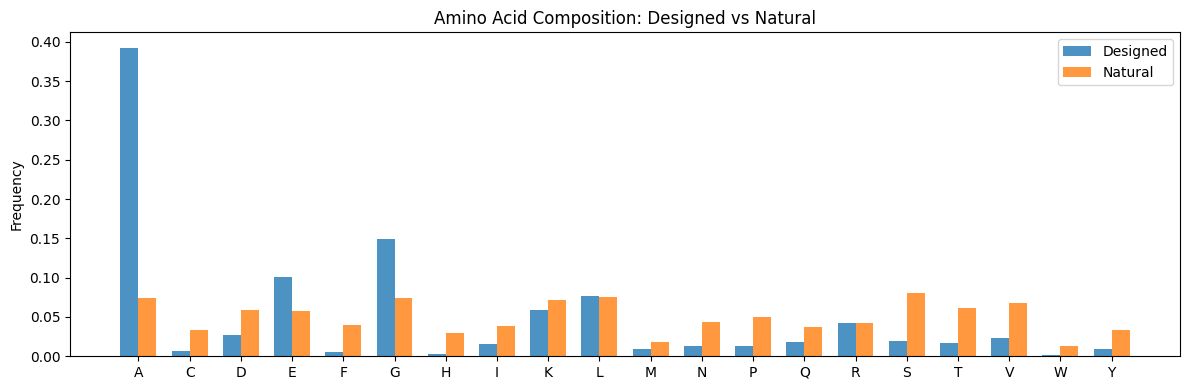

In [ ]:
# ============================================================
# Cell 5: Quick sequence analysis
# ============================================================
# Check that designed sequences have reasonable properties

import numpy as np
import matplotlib.pyplot as plt

# Amino acid composition — are the sequences reasonable?
aa_counts = {}
for seq in df_sequences['binder_sequence']:
    for aa in seq:
        aa_counts[aa] = aa_counts.get(aa, 0) + 1

total_aa = sum(aa_counts.values())
aa_freq = {aa: count/total_aa for aa, count in sorted(aa_counts.items())}

# Natural amino acid frequencies (approximate)
natural_freq = {
    'A': 0.074, 'R': 0.042, 'N': 0.044, 'D': 0.059, 'C': 0.033,
    'E': 0.058, 'Q': 0.037, 'G': 0.074, 'H': 0.029, 'I': 0.038,
    'L': 0.076, 'K': 0.072, 'M': 0.018, 'F': 0.040, 'P': 0.050,
    'S': 0.081, 'T': 0.062, 'W': 0.013, 'Y': 0.033, 'V': 0.068
}

fig, ax = plt.subplots(figsize=(12, 4))
aas = sorted(aa_freq.keys())
x = np.arange(len(aas))
width = 0.35
ax.bar(x - width/2, [aa_freq.get(aa, 0) for aa in aas], width, label='Designed', alpha=0.8)
ax.bar(x + width/2, [natural_freq.get(aa, 0) for aa in aas], width, label='Natural', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(aas)
ax.set_ylabel('Frequency')
ax.set_title('Amino Acid Composition: Designed vs Natural')
ax.legend()
plt.tight_layout()
plt.savefig('aa_composition.png', dpi=150)
plt.show()

# FLAG: If you see dramatically overrepresented amino acids (e.g., >20% leucine)
# or underrepresented ones (e.g., 0% cysteine is fine, 0% glycine is suspicious),
# the temperature or chain specification may need adjusting.

In [ ]:
# ============================================================
# Cell: Per-position entropy analysis
# ============================================================
# For each backbone, align the 8 ProteinMPNN samples and
# compute Shannon entropy at each position.
# Low entropy = model is confident → fix this position.
# High entropy = model is uncertain → degenerate with NNK.

import numpy as np
import pandas as pd
from collections import Counter

from google.colab import drive
drive.mount("/content/drive")


def shannon_entropy(column):
    counts = Counter(column)
    total = len(column)
    probs = [c / total for c in counts.values()]
    return -sum(p * np.log2(p) for p in probs if p > 0)

HIGH_ENTROPY_THRESHOLD = 0.5  # bits — positions above this are "tolerant"

SEQUENCE_CSV = "/content/drive/Othercomputers/My Mac/pdl1-mini-binder-design/data/results/proteinmpnn/all_mpnn_sequences.csv"
OUTPUT_PATH = "/content/drive/Othercomputers/My Mac/pdl1-mini-binder-design/data/results/proteinmpnn/position_entropy.csv"


# Load sequences if not already in memory
if "df_sequences" not in dir():
    df_sequences = pd.read_csv(SEQUENCE_CSV)

# Filter out the G-only dummy sequence (score=2.x, first row per backbone)
df_real = df_sequences[df_sequences["mpnn_score"] < 1.5].copy()

entropy_records = []

for backbone, group in df_real.groupby("backbone"):
    seqs = group["binder_sequence"].dropna().tolist()

    if len(seqs) < 2:
        continue

    # Verify all sequences are the same length before aligning
    lengths = [len(s) for s in seqs]
    if len(set(lengths)) > 1:
        print(f"Warning: {backbone} has variable-length sequences {lengths}, skipping")
        continue

    seq_len = lengths[0]

    for pos in range(seq_len):
        column = [s[pos] for s in seqs]
        n_unique = len(set(column))
        entropy = shannon_entropy(column)
        consensus = Counter(column).most_common(1)[0][0]

        entropy_records.append({
            "backbone": backbone,
            "position": pos + 1,       # 1-indexed
            "consensus_aa": consensus,
            "n_unique_aa": n_unique,
            "entropy_bits": round(entropy, 4),
            "is_tolerant": entropy > HIGH_ENTROPY_THRESHOLD,
            "residues_seen": "".join(sorted(set(column))),
        })

df_entropy = pd.DataFrame(entropy_records)

# Summary per backbone
summary = df_entropy.groupby("backbone").agg(
    seq_length=("position", "max"),
    n_fixed=("is_tolerant", lambda x: (~x).sum()),
    n_tolerant=("is_tolerant", "sum"),
    mean_entropy=("entropy_bits", lambda x: round(x.mean(), 3)),
    max_entropy=("entropy_bits", lambda x: round(x.max(), 3)),
).reset_index()

summary["library_size_log10"] = (summary["n_tolerant"] * np.log10(20)).round(1)
summary["library_size"] = summary["n_tolerant"].apply(lambda n: f"20^{n}")

print("Per-backbone entropy summary:")
print(summary.to_string(index=False))

# Focused view: validated backbones only
validated_backbones = ["design_1_0", "design_7_0", "design_23_0", "design_6_0"]
print("\nValidated designs:")
print(summary[summary["backbone"].isin(validated_backbones)].to_string(index=False))

# Save full position-level table
df_entropy.to_csv(OUTPUT_PATH, index=False)
print(f"\nSaved per-position entropy to {OUTPUT_PATH}")

# Save summary
summary_path = OUTPUT_PATH.replace("position_entropy.csv", "entropy_summary.csv")
summary.to_csv(summary_path, index=False)
print(f"Saved backbone summary to {summary_path}")

Mounted at /content/drive
Per-backbone entropy summary:
   backbone  seq_length  n_fixed  n_tolerant  mean_entropy  max_entropy  library_size_log10 library_size
 design_0_0          70       30          40         0.589        1.906                52.0        20^40
design_10_0          70       24          46         0.686        2.250                59.8        20^46
design_11_0          70       19          51         0.777        1.906                66.4        20^51
design_12_0          70       14          56         0.942        1.906                72.9        20^56
design_13_0          70       21          49         0.839        2.156                63.8        20^49
design_14_0          70       25          45         0.668        1.906                58.5        20^45
design_15_0          70       20          50         0.832        2.156                65.1        20^50
design_16_0          70       33          37         0.521        1.906                48.1        20^37